In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("System-Data-Qtr-Hourly-2025-v2.csv")

In [3]:
df.columns

Index(['DateTime', 'GMT Offset', 'NI Generation', 'NI Demand',
       'NI Wind Availability', 'NI Wind Generation', 'NI Solar Availability',
       'NI Solar Generation', 'Moyle I/C', 'NI Wind Penetration',
       'NI Solar Penetration', 'IE Generation', 'IE Demand',
       'IE Wind Availability', 'IE Wind Generation', 'IE Solar Availability',
       'IE Solar Generation', 'IE Hydro', 'EWIC I/C', 'IE Wind Penetration',
       'IE Solar Penetration', 'AI Generation', 'AI Demand',
       'AI Wind Availability', 'AI Wind Generation', 'AI Solar Availability',
       'AI Solar Generation', 'AI Hydro', 'Inter-Jurisdictional Flow',
       'AI Wind Penetration', 'AI Solar Penetration', 'AI Oversupply',
       'AI Oversupply Percentage', 'SNSP', 'Unnamed: 34', 'Unnamed: 35',
       'Unnamed: 36'],
      dtype='str')

In [4]:
df = df[['DateTime', 'AI Demand']].rename(columns={
    'DateTime': 'timestamp_utc',
    'AI Demand': 'load_MW'
})
df.to_csv('load_data.csv', index=False)

In [5]:
df.head(10)

,timestamp_utc,load_MW
0,1/1/2025 0:00,4061.751
1,1/1/2025 0:15,4015.779
2,1/1/2025 0:30,3971.138
3,1/1/2025 0:45,3937.172
4,1/1/2025 1:00,3924.215
5,1/1/2025 1:15,3888.057
6,1/1/2025 1:30,3844.500
7,1/1/2025 1:45,3791.549
8,1/1/2025 2:00,3812.066
9,1/1/2025 2:15,3773.562


In [6]:
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True)

In [7]:
df.head(10)

,timestamp_utc,load_MW
0,2025-01-01 00:00:00+00:00,4061.751
1,2025-01-01 00:15:00+00:00,4015.779
2,2025-01-01 00:30:00+00:00,3971.138
3,2025-01-01 00:45:00+00:00,3937.172
4,2025-01-01 01:00:00+00:00,3924.215
5,2025-01-01 01:15:00+00:00,3888.057
6,2025-01-01 01:30:00+00:00,3844.500
7,2025-01-01 01:45:00+00:00,3791.549
8,2025-01-01 02:00:00+00:00,3812.066
9,2025-01-01 02:15:00+00:00,3773.562


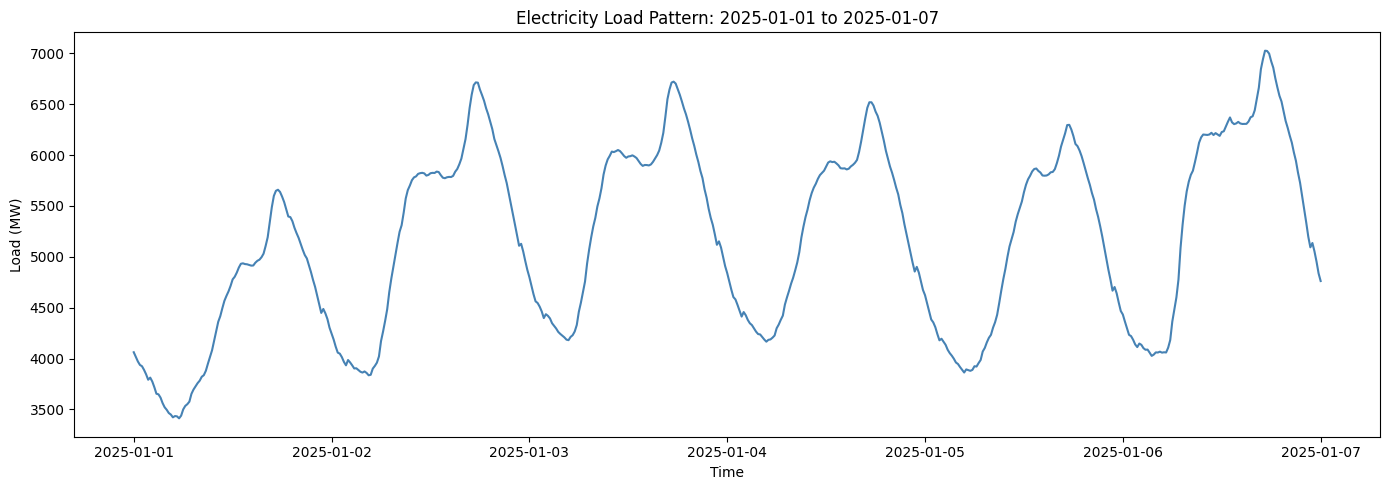

In [8]:
start_date = "2025-01-01"
end_date = "2025-01-07"  

df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)

start = pd.Timestamp(start_date, tz="UTC")
end = pd.Timestamp(end_date, tz="UTC")

week_df = df.query("@start <= timestamp_utc <= @end")

plt.figure(figsize=(14, 5))
plt.plot(week_df["timestamp_utc"], week_df["load_MW"], color="steelblue")

plt.title(f"Electricity Load Pattern: {start_date} to {end_date}")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.tight_layout()
plt.show()

In [9]:
import torch, platform, os

device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
dtype = torch.bfloat16 if (device == 'cuda' and torch.cuda.is_bf16_supported()) else torch.float32
print(f'Running on {device.upper()} (dtype={dtype})')
print(torch.cuda.get_device_name(0))  

Running on CUDA (dtype=torch.bfloat16)
NVIDIA GeForce RTX 4050 Laptop GPU


In [68]:
# CSV_PATH="load_data.csv"
# TIMESTAMP_COLUMN = 'timestamp_utc'
# TARGET_COLUMNS   = ['load_MW']
# ID_COLUMNS       = []                             # list of id columns, or [] if single series.
# CONTEXT_LENGTH   = 512                            # 512 for "ibm-granite/granite-timeseries-patchtst"
# FORECAST_HORIZON = 96                             # 96 for "ibm-granite/granite-timeseries-patchtst"
# TRAIN_FRAC, VALID_FRAC = 0.8, 0.1


## --- USER CONFIG - for pre-training ---
CSV_PATH          = 'load_data.csv'
TIMESTAMP_COLUMN  = 'timestamp_utc'
TARGET_COLUMNS    = ['load_MW']
ID_COLUMNS        = []                  # list of id columns, or [] if single series.
CONTEXT_LENGTH    = 168                 # one week
FORECAST_HORIZON  = 24                  # 24 hours
TRAIN_FRAC, VALID_FRAC = 0.8, 0.1
PATCH_LENGTH      = 12
BATCH_SIZE        = 32
NUM_WORKERS       = 8
DATASET_NAME      = "irish_electricity"
# # ---------------------------------
# # the above will give about 8k rows. Ideally, perhaps 10k+ are needed for a single channel model.

In [69]:
import pandas as pd
from tsfm_public.toolkit.util import select_by_index

df = pd.read_csv(CSV_PATH, parse_dates=[TIMESTAMP_COLUMN])
print(df.head())

n = len(df)
train_end = int(n * TRAIN_FRAC)
valid_end = int(n * (TRAIN_FRAC + VALID_FRAC))

train_df = select_by_index(df, start_index=None, end_index=train_end)
valid_df = select_by_index(df, start_index=train_end - CONTEXT_LENGTH, end_index=valid_end)
test_df  = select_by_index(df, start_index=valid_end - CONTEXT_LENGTH, end_index=None)

        timestamp_utc   load_MW
0 2025-01-01 00:00:00  4061.751
1 2025-01-01 00:15:00  4015.779
2 2025-01-01 00:30:00  3971.138
3 2025-01-01 00:45:00  3937.172
4 2025-01-01 01:00:00  3924.215


In [70]:
from tsfm_public.toolkit.time_series_preprocessor import TimeSeriesPreprocessor
from tsfm_public.toolkit.dataset import ForecastDFDataset

tsp = TimeSeriesPreprocessor(timestamp_column=TIMESTAMP_COLUMN,
                             id_columns=ID_COLUMNS,
                             target_columns=TARGET_COLUMNS,
                             scaling="std") # True means scaling uses mean
tsp.train(train_df)

def make_ds(raw):
    return ForecastDFDataset(
        tsp.preprocess(raw),
        id_columns=ID_COLUMNS,
        target_columns=TARGET_COLUMNS,
        context_length=CONTEXT_LENGTH,
        prediction_length=FORECAST_HORIZON
    )

train_ds, valid_ds, test_ds = map(make_ds, [train_df, valid_df, test_df])
print(f"train={len(train_ds)}, valid={len(valid_ds)}, test={len(test_ds)}")

train=6717, valid=841, test=841


In [62]:
# # Preprocess with padding (uses ts_padding_utils.py) - allows you to use models trained for longer context
# # Import the padding utilities
# from ts_padding_utils import preprocess_with_padding

# # Set your padding parameter (set to None to disable padding)
# PAD_TO_LENGTH = 512  # Example: pad to match the pretrained model's context length of 512

# # Use the utility function to preprocess data with padding
# train_ds, valid_ds, test_ds, tsp = preprocess_with_padding(
#     df=df,
#     timestamp_column=TIMESTAMP_COLUMN,
#     id_columns=ID_COLUMNS,
#     target_columns=TARGET_COLUMNS,
#     train_frac=TRAIN_FRAC,
#     valid_frac=VALID_FRAC,
#     context_length=CONTEXT_LENGTH,
#     forecast_horizon=FORECAST_HORIZON,
#     pad_to_length=PAD_TO_LENGTH  # Set to None to disable padding
# )

# print(f"train={len(train_ds)}, valid={len(valid_ds)}, test={len(test_ds)}")

In [71]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def compute_metrics(eval_pred):
    pred, labels = eval_pred
    pred         = pred[0] if isinstance(pred, tuple) else pred
    C            = len(TARGET_COLUMNS)
    
    scaler = next(iter(tsp.target_scaler_dict.values()))
    pred   = scaler.inverse_transform(pred.reshape(-1, C)).reshape(pred.shape)
    labels = scaler.inverse_transform(labels.reshape(-1, C)).reshape(labels.shape)
    
    pred   = pred.reshape(-1)
    labels = labels.reshape(-1)
    
    mae  = mean_absolute_error(labels, pred)
    rmse = np.sqrt(mean_squared_error(labels, pred))
    mape = 100 * np.mean(np.abs((labels - pred) / (np.abs(labels) + 1e-9)))
    return {"mae": mae, "rmse": rmse, "mape": mape}

In [74]:
import matplotlib.pyplot as plt

def evaluate_and_visualize(model, test_dataset, tsp):
    """
    Evaluate PatchTST model, calculate metrics, and visualize predictions
    """
    # Setup trainer for prediction
    trainer = Trainer(
        model=model,
        args=TrainingArguments(
            output_dir='metric_tmp',
            label_names=['future_values'],
            bf16=False,   # disable bfloat16
            fp16=False,   # disable float16
        )
    )
    
    # Get predictions
    outputs = trainer.predict(test_dataset)
    predictions = outputs.predictions[0] if isinstance(outputs.predictions, tuple) else outputs.predictions
    labels = outputs.label_ids
    
    # Get number of target columns
    C = len(TARGET_COLUMNS)
    
    # Use the same inverse_transform method as in compute_metrics
    scaler = next(iter(tsp.target_scaler_dict.values()))
    pred_original = scaler.inverse_transform(predictions.reshape(-1, C)).reshape(predictions.shape)
    # Use the same inverse_transform method as in compute_metrics
    scaler = next(iter(tsp.target_scaler_dict.values()))
    pred_original = scaler.inverse_transform(predictions.reshape(-1, C)).reshape(predictions.shape)
    label_original = scaler.inverse_transform(labels.reshape(-1, C)).reshape(labels.shape)

    # Calculate metrics on flattened arrays
    pred_flat = pred_original.reshape(-1)
    label_flat = label_original.reshape(-1)

    metrics = {
        'mae': mean_absolute_error(label_flat, pred_flat),
        'rmse': np.sqrt(mean_squared_error(label_flat, pred_flat)),
        'mape': 100 * np.mean(np.abs((label_flat - pred_flat) / (np.abs(label_flat) + 1e-10)))
    }

    print(f"\nMetrics:")
    print(f"MAE: {metrics['mae']:.2f} MW")
    print(f"RMSE: {metrics['rmse']:.2f} MW")
    print(f"MAPE: {metrics['mape']:.2f}%")

    # Plot a sample forecast
    plt.figure(figsize=(12, 6))

    # Plot a sample forecast
    plt.figure(figsize=(12, 6))
    sample_idx = 0
    horizon = FORECAST_HORIZON

    plt.plot(np.arange(horizon), label_original[sample_idx, :horizon, 0], 'b-', label='Actual')
    plt.plot(np.arange(horizon), pred_original[sample_idx, :horizon, 0], 'r--', label='Forecast')
    plt.xlabel('Hours ahead')
    plt.ylabel('Load (MW)')
    plt.title(f"Load Forecast\nMAE: {metrics['mae']:.2f} MW, RMSE: {metrics['rmse']:.2f} MW, MAPE: {metrics['mape']:.2f}%")
    plt.legend()
    plt.grid(True)
    plt.show()

    return {
        'mae': metrics['mae'],
        'rmse': metrics['rmse'],
        'mape': metrics['mape'],
        'predictions': pred_original,
        'labels': label_original
    }

In [65]:
from transformers import PatchTSTForPrediction, PatchTSTConfig, TrainingArguments, Trainer
BASE_MODEL = "ibm-granite/granite-timeseries-patchtst"

# First, load the config and modify it
config = PatchTSTConfig.from_pretrained(BASE_MODEL)
config.num_input_channels = 1  # Set to match your single column. This is necessary because the pretrained model here is trained

print(config.patch_length)

# Then use the modified config when loading the model
model = PatchTSTForPrediction.from_pretrained(
    BASE_MODEL,
    config=config
).to(device).to(torch.float32)

# eval_args = TrainingArguments(output_dir='eval_tmp', label_names=['future_values'])
# baseline_trainer = Trainer(model=model, args=eval_args, compute_metrics=compute_metrics)
# baseline_metrics = baseline_trainer.evaluate(test_ds)
# print(baseline_metrics)

12


Evaluating and visualizing model...



Metrics:
MAE: 584.20 MW
RMSE: 686.69 MW
MAPE: 12.13%


<Figure size 1200x600 with 0 Axes>

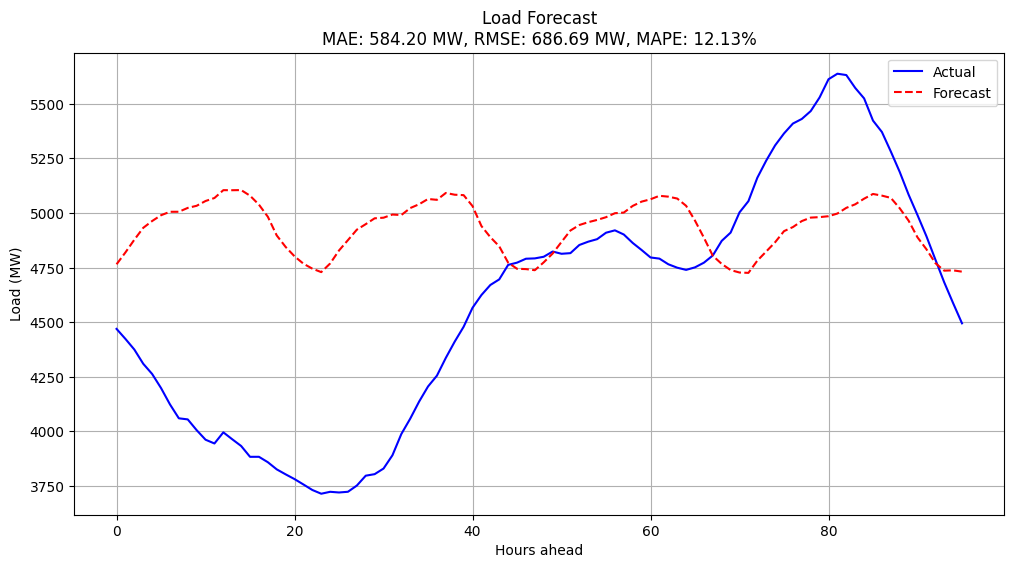

In [32]:
# Evaluate and visualize the model
print("Evaluating and visualizing model...")
results = evaluate_and_visualize(model, test_ds, tsp)

In [72]:
from transformers import (
    EarlyStoppingCallback,
    PatchTSTConfig,
    PatchTSTForPrediction,
    Trainer,
    TrainingArguments,
)

device = (
    torch.device("cuda") if torch.cuda.is_available()
    else torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)

dtype = torch.bfloat16 if device.type == "cuda" else torch.float32
print(f"Running on {device} | dtype={dtype}")

config = PatchTSTConfig(
    do_mask_input=False,
    context_length=CONTEXT_LENGTH,
    patch_length=PATCH_LENGTH,
    num_input_channels=len(TARGET_COLUMNS),
    patch_stride=PATCH_LENGTH,
    prediction_length=FORECAST_HORIZON,
    d_model=128,
    num_attention_heads=16,
    num_hidden_layers=3,
    ffn_dim=512,
    dropout=0.2,
    head_dropout=0.2,
    pooling_type=None,
    channel_attention=False,
    scaling="std",
    loss="mse",
    pre_norm=True,
    norm_type="batchnorm",
)

model = PatchTSTForPrediction(
    config=config
).to(device=device, dtype=dtype)

# # or load a pretrained model
# model = PatchTSTForPrediction.from_pretrained(BASE_MODEL, torch_dtype=dtype).to(device=device, dtype=dtype)

Running on cuda | dtype=torch.bfloat16


In [48]:
# # TO ADD LORA - won't work if pre-training from scratch
# from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType
# from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

# lora_cfg = LoraConfig(
#     task_type=TaskType.FEATURE_EXTRACTION,
#     r=8, lora_alpha=16, lora_dropout=0.05,
#     target_modules=['q_proj', 'v_proj', 'q_proj', 'out_proj', 'projection', 'input_embedding'],
#     modules_to_save=[''],
#     bias='none'
# )

# model = PatchTSTForPrediction.from_pretrained(BASE_MODEL, torch_dtype=dtype)
# # model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=False) # only needed if quantizing
# model = get_peft_model(model, lora_cfg)
# model.print_trainable_parameters()

In [73]:
train_args = TrainingArguments(
    output_dir="./checkpoint/patchtst/direct/train/output/",
    overwrite_output_dir=True,
    learning_rate=0.0001,
    num_train_epochs=5,
    do_eval=True,
    eval_strategy="epoch",
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    dataloader_num_workers=NUM_WORKERS,
    save_strategy="epoch",
    logging_strategy="epoch",
    save_total_limit=1,
    fp16=(dtype==torch.float16),
    bf16=(dtype==torch.bfloat16),
    logging_dir="./checkpoint/patchtst/direct/train/logs/",  # Make sure to specify a logging directory
    load_best_model_at_end=True,  # Load the best model when training ends
    metric_for_best_model="eval_loss",  # Metric to monitor for early stopping
    greater_is_better=False,  # For loss
    label_names=["future_values"],
)

# Create a new early stopping callback with faster convergence properties
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=5,  # Number of epochs with no improvement after which to stop
    early_stopping_threshold=0.001,  # Minimum improvement required to consider as improvement
)

trainer = Trainer(
    model=model,
    args=train_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    callbacks=[early_stopping_callback],
    compute_metrics=compute_metrics,
)

print(f"\n\nDoing forecasting training on {DATASET_NAME}")
trainer.train()



Doing forecasting training on irish_electricity


Epoch,Training Loss,Validation Loss,Mae,Rmse,Mape
1,0.200100,0.065798,161.618088,214.575116,3.205028
2,0.092000,0.051050,141.936737,189.004557,2.845220
3,0.073900,0.044275,128.517899,176.015547,2.562336
4,0.067600,0.044959,130.595001,177.371438,2.616404
5,0.065100,0.045585,131.840286,178.601763,2.643446


TrainOutput(global_step=1050, training_loss=0.09972904023670015, metrics={'train_runtime': 891.748, 'train_samples_per_second': 37.662, 'train_steps_per_second': 1.177, 'total_flos': 21710500398720.0, 'train_loss': 0.09972904023670015, 'epoch': 5.0})

In [75]:
output = trainer.predict(test_ds)

In [76]:
output.predictions[0].shape

(841, 24, 1)

In [77]:
from pathlib import Path
save_dir = Path('save_dir')
model.save_pretrained(save_dir)
print('Model or adapter saved to', save_dir.resolve())

# Optional:
# from huggingface_hub import login; login()
# model.push_to_hub('your-username/patchtst-lora-generic')

Model or adapter saved to C:\Users\LENOVO\Desktop\Time-Series-Forecasting-with-Transformers\save_dir


Evaluating and visualizing model...



Metrics:
MAE: 164.93 MW
RMSE: 232.90 MW
MAPE: 3.40%


<Figure size 1200x600 with 0 Axes>

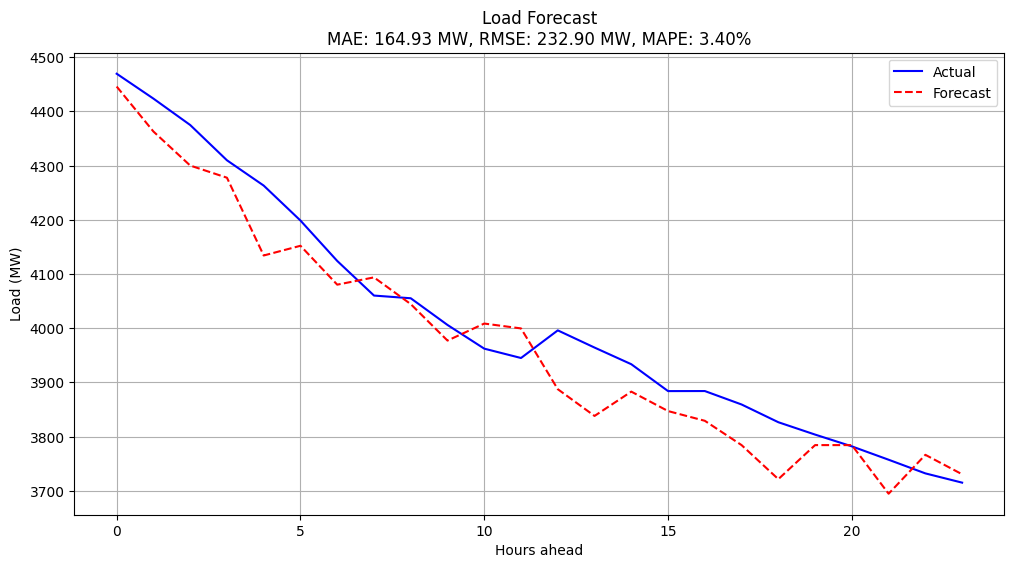

In [78]:
# ft_metrics = trainer.evaluate(test_ds)
# print('Baseline:', baseline_metrics)
# print('Fine-tuned:', ft_metrics)

# Evaluate and visualize the model
print("Evaluating and visualizing model...")
results = evaluate_and_visualize(model, test_ds, tsp)

# eval_args = TrainingArguments(output_dir='eval_tmp', label_names=['future_values'])
# baseline_trainer = Trainer(model=model, args=eval_args)
# baseline_metrics = baseline_trainer.evaluate(test_ds)
# print(baseline_metrics)